# **Homework 3**

*Artificial Intelligence II - Fall Semester 2021*

*Deep Learning for Natural Language Processing*


---



## **Experiment 2: GRU**

Mount Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### **Imports**

Import needed libraries and download packages "punkt" and "popular"

In [2]:
import pandas as pd
import scipy
from string import digits
import re

import matplotlib.pyplot as plt

import numpy as np
import nltk

nltk.download('punkt')
nltk.download('popular')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn import preprocessing
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score
from scipy import spatial
from sklearn.manifold import TSNE
from sklearn.preprocessing import binarize, MultiLabelBinarizer
import warnings
from scipy import interp
import unicodedata
import string

# from functools import reduce
# import operator
from itertools import cycle

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchtext.vocab import GloVe, FastText
from torchtext.legacy.data import Field, Dataset, Example, BucketIterator
from torch.nn.utils.rnn import pad_sequence


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading collection 'popular'
[nltk_data]    | 
[nltk_data]    | Downloading package cmudict to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/cmudict.zip.
[nltk_data]    | Downloading package gazetteers to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/gazetteers.zip.
[nltk_data]    | Downloading package genesis to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/genesis.zip.
[nltk_data]    | Downloading package gutenberg to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/gutenberg.zip.
[nltk_data]    | Downloading package inaugural to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/inaugural.zip.
[nltk_data]    | Downloading package movie_reviews to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping corpora/movie_reviews.zip.
[nltk_data]    | Downloading package names to /root/nltk_data...
[nltk_data]    | 

Read train data from csv file.

In [4]:
df_train = pd.read_csv("/content/drive/MyDrive/VaccineSentimentDataset/vs_train.csv", index_col=[0])
df_train.head()

,tweet,label
0,Sip N Shop Come thru right now #Marjais #Popul...,0
1,I don't know about you but My family and I wil...,1
2,@MSignorile Immunizations should be mandatory....,2
3,President Obama spoke in favor of vaccination ...,0
4,"""@myfoxla: Arizona monitoring hundreds for mea...",0


Read test data from csv file.

In [5]:
df_test = pd.read_csv("/content/drive/MyDrive/VaccineSentimentDataset/vs_dev.csv", index_col=[0])
df_test.head()

,tweet,label
0,@user They had a massive surge in with covid d...,1
1,Required vaccines for school: Parents and guar...,0
2,“@KCStar: Two more Johnson County children hav...,0
3,NV can do better. Which states are the best (a...,2
4,Nothing like killing ourselves w/ our own fear...,2


## **Data Preprocess**



---



###Text Data Cleaning

>For the data cleaning process, the following were included: 
* Remove all whitespaces and newlines 
* Remove all special characters and punctuation
* Replace contractions with full words (despite that they might be removed   later from the stopwords)
* Splitted attached words e.g.  “ForTheWin” =>  “For The Win”
* Lowered all capital letters  
* Removed Numbers from text corpus
* Standarizing sentences

>Both train and test data are preprocessed in the same exact way.

>(reference link: [python-efficient-text-data-cleaning](https://www.geeksforgeeks.org/python-efficient-text-data-cleaning/)

In [6]:
def numbers(x):
  return re.sub(r'[0-9]+', '', x)

def blank_space(x):
  return re.sub('[^A-Za-z0-9]+', ' ', x)

def standarize_sentence(x):
  return ''.join(''.join(word)[:2] for word in x) 

def apostrophe_words(x):
  Apos_dict={"'s":" is","'t":" not","'m":" am","'ll":" will", "'d":" would","'ve":" have","'re":" are", 
             "’s":" is","’t":" not","’m":" am", "’d":" would","’ve":" have","’re":" are", "’ll": "will"} 
  for key,value in Apos_dict.items(): 
    if key in x:
      x =  x.replace(key,value)
      return x
  return x

def split_words(x):
  return " ".join([word for word in re.split("([A-Z][a-z]+[^A-Z]*)",x) if word])

def shallow_cleaning(df):
  remove_digits = str.maketrans('', '', digits)
  df['tweet'] = df['tweet'].apply(lambda x: blank_space(x))
  df['tweet'] = df['tweet'].apply(lambda x: apostrophe_words(x))
  df['tweet'] = df['tweet'].str.strip()
  df['tweet'] = df['tweet'].str.lower()
  df['tweet'] = df['tweet'].apply(lambda x: numbers(x))
  df['tweet'] = df['tweet'].apply(lambda x: split_words(x))
  df['tweet'] = df['tweet'].apply(lambda x: standarize_sentence(x))
  return df

df_train = shallow_cleaning(df_train)
display(df_train)

,tweet,label
0,sip n shop come thru right now marjais popular...,0
1,i don t know about you but my family and i wil...,1
2,msignorile immunizations should be mandatory p...,2
3,president obama spoke in favor of vaccination ...,0
4,myfoxla arizona monitoring hundreds for measle...,0
...,...,...
15971,salon if u believe the anti vax nutcases cause...,1
15972,how do you feel about parents who don t vaccin...,0
15973,preschoolers tested for measles in simi valle...,0
15974,finance minister budget offers room to procure...,0


In [7]:
df_test = shallow_cleaning(df_test)
display(df_test)

,tweet,label
0,user they had a massive surge in with covid de...,1
1,required vaccines for school parents and guard...,0
2,kcstar two more johnson county children have m...,0
3,nv can do better which states are the best and...,2
4,nothing like killing ourselves w our own fear ...,2
...,...,...
2277,rt abc number of measles cases reported in cal...,0
2278,evidence points to the idea that measles affec...,0
2279,where s savedyouaclick voxdotcom why you shoul...,2
2280,some of my favorite people have autism if that...,2


Mount available CUDA device

In [8]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using {device} device')

Using cuda device


In [9]:
!nvidia-smi -q


==============NVSMI LOG==============

Timestamp                                 : Sun Jan 30 17:13:07 2022
Driver Version                            : 460.32.03
CUDA Version                              : 11.2

Attached GPUs                             : 1
GPU 00000000:00:04.0
    Product Name                          : Tesla K80
    Product Brand                         : Tesla
    Product Architecture                  : Kepler
    Display Mode                          : Disabled
    Display Active                        : Disabled
    Persistence Mode                      : Disabled
    MIG Mode
        Current                           : N/A
        Pending                           : N/A
    Accounting Mode                       : Disabled
    Accounting Mode Buffer Size           : 4000
    Driver Model
        Current                           : N/A
        Pending                           : N/A
    Serial Number                         : 0322016014528
    GPU UUID            

### Load ***GloVe*** embeddings

GloVe is an unsupervised learning algorithm for obtaining vector representations for words. Training is performed on aggregated global word-word co-occurrence statistics from a corpus, and the resulting representations showcase interesting linear substructures of the word vector space.


---

**GloVe** embedding vector is downloaded and initialized. Since the dataset we are provided is from twitter, the chosen embedding is the Twitter dataset containing 27 billion parameters and 100 dimensions.

In [10]:
glove_embedding = GloVe(name = 'twitter.27B', dim = 100)

.vector_cache/glove.twitter.27B.zip: 1.52GB [04:45, 5.32MB/s]                            
100%|█████████▉| 1193513/1193514 [01:10<00:00, 16924.37it/s]


In [11]:
glove_embedding_expanded = glove_embedding.vectors.unsqueeze(0) # add the batch_size dimension
h0 = torch.zeros(1, 1, 50)           # initial hidden state

print(glove_embedding_expanded.shape)

torch.Size([1, 1193514, 100])


***max_row_len(df):*** takes the dataframe and finds the longest tweet in words which sets the upper limit for the embedding we are going to use.

In [12]:
def max_row_len(df):
  max_len = 0
  for i, r in df.iterrows():
    max_len = max(max_len, len(r['tweet'].split()))
  return max_len

max_len = max_row_len(df_train)
print(max_len)

101


## Preprocessing & Vocabulary Creation

*   Create Fields
*   Basic preprocessing for the input dataset (train & test) - tokenization and lowercase
*   Build vocabulary 


---


>**Field:**
>
>Defines a datatype together with instructions for converting to Tensor.
>
>Field class models common text processing datatypes that can be represented by tensors. It holds a Vocab object that defines the set of possible values for elements of the field and their corresponding numerical representations. The Field object also holds other parameters relating to how a datatype should be numericalized, such as a tokenization method and the kind of Tensor that should be produced.


In [13]:
#create fields
text_field = Field(
    sequential=True,
    tokenize='spacy', 
    fix_length=max_len,
    lower=True,
    stop_words = 'english'
)

text_field_test = Field(
    sequential=True,
    tokenize='spacy', 
    fix_length=max_len,
    lower=True,
    stop_words = 'english'
)

df_train['tweet'] = df_train['tweet'].astype('string')

df_test['tweet'] = df_test['tweet'].astype('string')

#basic preprocessing
preprocessed_text = df_train['tweet'].apply(
    lambda x: text_field.preprocess(x)
).astype('string')

preprocessed_text_test = df_test['tweet'].apply(
    lambda x: text_field_test.preprocess(x)
).astype('string')

label_field = Field(sequential=False, use_vocab=False, is_target=True, dtype=torch.long)
index_field = Field(sequential=False, use_vocab=False, is_target=True, dtype=torch.long)

label_field_test = Field(sequential=False, use_vocab=False, is_target=True, dtype=torch.long)
index_field_test = Field(sequential=False, use_vocab=False, is_target=True, dtype=torch.long)

#build vocabularies
text_field.build_vocab(
    preprocessed_text, 
    vectors=glove_embedding
)

text_field_test.build_vocab(
    preprocessed_text_test, 
    vectors=glove_embedding
)

## Dataset Creation

Dataframe definition with the use of the DataFrame object.


In [14]:
class DataFrameDataset(Dataset):
  def __init__(self, df: pd.DataFrame, fields: list):
    super(DataFrameDataset, self).__init__(
        [
            Example.fromlist(list(r), fields) 
            for i, r in df.iterrows()
        ], fields
      )

Define the train and test dataset

In [15]:
train_dataset = DataFrameDataset(
    df=df_train.reset_index(), 
    fields=(
        ('index', index_field),
        ('tweet', text_field),
        ('label', label_field)
    )
)

test_dataset = DataFrameDataset(
    df=df_test.reset_index(), 
    fields=(
        ('index', index_field_test),
        ('tweet', text_field_test),
        ('label', label_field_test)
    )
)

Iterator construction for the mini batches used in the model.

***Batch-size=64***

In [16]:
train_iter, val_iter = BucketIterator.splits(
    datasets=(train_dataset, train_dataset), 
    batch_sizes=(64, 64),
    sort=False,
    device = device,
    shuffle = True
)

#mock_iter is never used, it is needed for the BuckeIterator to work properly as 
#I have gathered after many hours of searching on Google...
test_iter, mock_iter = BucketIterator.splits(
    datasets=(test_dataset, test_dataset), 
    batch_sizes=(64, 64),
    sort=False,
    device = device,
    shuffle = True
)

In [17]:
def getMax(array, size):
  max = -1
  counter = 0
  for element in array:
    if max < element:
      max = element
      label = counter
    counter+=1
  return label

def getPrediction(y_pred, out_dim=1):
  res_list = []
  for line in y_pred:
    res_list.append(getMax(line, 3))
  res_df = pd.DataFrame(data=res_list, columns=['Predicted Labels'])
  if device == 'cuda':
    return torch.tensor(res_df.values, dtype=torch.long).to('cuda')
  else:
    return torch.tensor(res_df.values, dtype=torch.long)

### Define Neural Network

**Architecture:** 



*   Pretrained Embedding layer - GloVe - with vector dimensions as defined in  above code sections
*   GRU layer: fed from the embedding layer, bidirectional with dropout 0.7
*   Linear layer with input_size self.input_size and output=output_size





In [18]:
class TweetRNN(nn.Module):
    def __init__(self, embedding, input_size, embedding_size, hidden_size, num_classes, num_layers=2):
        super().__init__()
        self.embedding = embedding
        self.input_size = input_size
        self.embedding_size = embedding_size
        self.hidden_size = hidden_size
        self.num_classes = num_classes
        self.num_layers = num_layers

        self.emb = nn.Embedding.from_pretrained(self.embedding)
        self.rnn = nn.GRU(input_size=self.embedding_size, hidden_size=self.hidden_size, bidirectional=True, batch_first=True, num_layers=self.num_layers, dropout=0.70)
        self.linear = nn.Linear(self.input_size, self.num_classes)
    
    def forward(self, x):
        x = self.emb(x)      
        rnn_out, _ = self.rnn(x)
        
        rnn_mean = None
        for i in range(self.input_size):
          if rnn_mean is None:
            rnn_mean = torch.mean(rnn_out[:,i,:], 1, True)
          else:
            rnn_mean = torch.hstack((rnn_mean, torch.mean(rnn_out[:,i,:], 1, True)))
        
        out = self.linear(rnn_mean)
        return out

### Model Initialization



*   input_size
*   hidden_size: hidden layer size
*   N_EPOCHS
*   num_layers: the number of layers the stacked RNN will have
*   Learning rate: after multiple experiments 0.005 is thought to be the best choice
*   Loss function: CrossEntropyLoss is used. It is considered the best choice for multiclass classiication problems.
*   Optimizer: Adam - has good performance overall.
*   Scheduler: ReduceLROnPlateau. For this implementation i used this particular scheduler (and generally a scheduler), since the model seem to get stuck in plateus during its training.



In [19]:
hidden_size = 64
N_EPOCHS = 200
num_layers = 3
input_size = 64
net = TweetRNN(embedding=glove_embedding.vectors, input_size=input_size, embedding_size=glove_embedding.vectors.shape[1], hidden_size=hidden_size, num_classes=3, num_layers=num_layers)

for name, param in net.named_parameters():
    if param.requires_grad:
        print(name, param.shape)

LR = 0.005
optimizer = torch.optim.Adam(net.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer=optimizer, mode='min', patience=5, factor=0.5, cooldown=1)

if device == 'cuda':
  net.to('cuda')
  criterion.to('cuda')

rnn.weight_ih_l0 torch.Size([192, 100])
rnn.weight_hh_l0 torch.Size([192, 64])
rnn.bias_ih_l0 torch.Size([192])
rnn.bias_hh_l0 torch.Size([192])
rnn.weight_ih_l0_reverse torch.Size([192, 100])
rnn.weight_hh_l0_reverse torch.Size([192, 64])
rnn.bias_ih_l0_reverse torch.Size([192])
rnn.bias_hh_l0_reverse torch.Size([192])
rnn.weight_ih_l1 torch.Size([192, 128])
rnn.weight_hh_l1 torch.Size([192, 64])
rnn.bias_ih_l1 torch.Size([192])
rnn.bias_hh_l1 torch.Size([192])
rnn.weight_ih_l1_reverse torch.Size([192, 128])
rnn.weight_hh_l1_reverse torch.Size([192, 64])
rnn.bias_ih_l1_reverse torch.Size([192])
rnn.bias_hh_l1_reverse torch.Size([192])
rnn.weight_ih_l2 torch.Size([192, 128])
rnn.weight_hh_l2 torch.Size([192, 64])
rnn.bias_ih_l2 torch.Size([192])
rnn.bias_hh_l2 torch.Size([192])
rnn.weight_ih_l2_reverse torch.Size([192, 128])
rnn.weight_hh_l2_reverse torch.Size([192, 64])
rnn.bias_ih_l2_reverse torch.Size([192])
rnn.bias_hh_l2_reverse torch.Size([192])
linear.weight torch.Size([3, 64])


In [20]:
net

TweetRNN(
  (emb): Embedding(1193514, 100)
  (rnn): GRU(100, 64, num_layers=3, batch_first=True, dropout=0.7, bidirectional=True)
  (linear): Linear(in_features=64, out_features=3, bias=True)
)

### Train Network

Epochs: 200 (after the conduction of multiple experiments)

The model is trained with the entire train dataset and then tested (as a mockup) with the same dataset.

In [21]:
train_loss = []
val_loss = []
y_test = []
prediction = []

train_stats = {'train_loss': [], 'val_loss': []}


for epoch in range(N_EPOCHS):
  batch_losses = []
  y_test = []
  prediction = []
  running_loss = 0.0
  i=0

  # Ensure net in training mode
  net.train()
  for batch in train_iter:
    # Zero out gradients
    optimizer.zero_grad()
    
    # Get net output, calculate loss, and generate gradients
    output = net(batch.tweet.T)
    loss = criterion(output, batch.label)
    # Generate gradients via autograd
    loss.backward() 
    
    # Step
    # -----------------------------------
    # Clip params
    for param in net.parameters():
        if param.grad is None:
            continue
        grad_val = torch.clamp(param.grad, -5, 5)
    optimizer.step()
    # -----------------------------------
    
    # Track loss
    # CE loss
    batch_losses.append(loss.item())
    current_loss = loss.item()
    running_loss += (current_loss - running_loss) / (i + 1)     

  print(f"Epoch {epoch:3}: Loss = {float(running_loss)}")

  train_stats['train_loss'].append(float(running_loss))
  
  # Compute the validation score
  net.eval()
  running_loss_val = 0.0

  for batch in val_iter:
    
    y_pred = net(batch.tweet.T)
    y_pred_label = getPrediction(y_pred, 3)
    
    loss = criterion(y_pred, batch.label)
    
    current_loss = loss.item()
    running_loss += (current_loss - running_loss) / (i + 1)
    
    prediction.append(y_pred_label.flatten().tolist())
    y_test.append(batch.label.cpu().tolist())
    i += 1

  train_stats['val_loss'].append(running_loss)
  scheduler.step(train_stats['val_loss'][-1])

prediction = sum(prediction, [])
y_test = sum(y_test, [])

Epoch   0: Loss = 1.0810378789901733
Epoch   1: Loss = 0.855402410030365
Epoch   2: Loss = 0.9388200640678406
Epoch   3: Loss = 0.9472082853317261
Epoch   4: Loss = 1.0551484823226929
Epoch   5: Loss = 1.0133594274520874
Epoch   6: Loss = 0.8394603729248047
Epoch   7: Loss = 1.0127910375595093
Epoch   8: Loss = 1.0209733247756958
Epoch   9: Loss = 0.9468559622764587
Epoch  10: Loss = 0.9743385314941406
Epoch  11: Loss = 0.9510889053344727
Epoch  12: Loss = 0.8899168968200684
Epoch  13: Loss = 0.9925650358200073
Epoch  14: Loss = 0.9651827216148376
Epoch  15: Loss = 0.8740159273147583
Epoch  16: Loss = 0.9636463522911072
Epoch  17: Loss = 0.8964336514472961
Epoch  18: Loss = 1.0806690454483032
Epoch  19: Loss = 1.0068323612213135
Epoch  20: Loss = 0.9584094285964966
Epoch  21: Loss = 0.9109188318252563
Epoch  22: Loss = 0.9785550236701965
Epoch  23: Loss = 0.9307799935340881
Epoch  24: Loss = 0.9937548637390137
Epoch  25: Loss = 0.9409984946250916
Epoch  26: Loss = 0.9267376065254211
Ep

### Train Classification Report

In [22]:
model_report = classification_report(y_test,prediction)
print(model_report)

              precision    recall  f1-score   support

           0       0.55      0.68      0.61      7458
           1       0.39      0.03      0.06      2073
           2       0.47      0.47      0.47      6445

    accuracy                           0.51     15976
   macro avg       0.47      0.40      0.38     15976
weighted avg       0.49      0.51      0.48     15976



Train Statistics Report


*   Train Loss: Model loss monitored during training phase
*   Val_Loss: Model loss monitored during evaluation phase



In [23]:
train_stats_df = pd.DataFrame(train_stats)
display(train_stats_df)

,train_loss,val_loss
0,1.081038,0.979042
1,0.855402,0.973663
2,0.938820,0.970235
3,0.947208,0.971943
4,1.055148,0.967341
...,...,...
195,0.945790,0.958600
196,0.940039,0.958836
197,1.101790,0.958943
198,0.950770,0.958637


Graphic represantation of train and evaluation loss for train dataset.

As the training progresses through the epochs, in this case the val_loss stays stable.

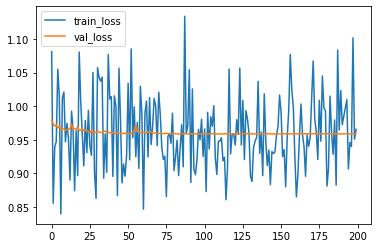

In [24]:
train_stats_df.plot()

Batch Losses

In [25]:
batch_losses_df = pd.DataFrame(batch_losses, columns=['Batch Loss'])
display(pd.DataFrame(batch_losses_df.T))

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,...,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249
Batch Loss,1.042511,0.949257,0.973421,1.058475,1.026775,0.918367,0.930261,0.894761,0.964274,0.949635,0.933589,1.026521,0.897078,1.058467,0.9471,0.968314,0.910437,0.966867,0.926484,0.935525,0.91255,0.898746,0.983262,0.92533,0.896804,0.999789,0.912522,0.939126,0.961194,1.037395,0.933472,0.982683,0.982248,0.96871,0.930473,0.997795,0.951328,0.95676,0.894906,0.963878,...,0.991611,0.883397,1.043257,0.98644,0.976678,1.066853,1.010527,0.957875,0.963835,0.916346,0.917976,0.999061,0.988615,1.019844,0.968417,1.033485,0.918727,1.062136,0.976104,0.994846,0.935574,0.925965,0.823703,1.061696,0.980704,0.897242,1.020362,0.850723,0.937268,0.960958,0.948684,0.977662,0.993919,0.857308,0.986832,0.856108,0.993404,1.001843,0.922525,0.965415


Graphic representation of batch losses

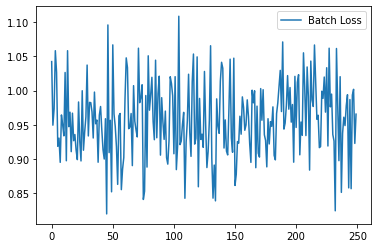

In [26]:
batch_losses_df.plot()

Save model

In [28]:
PATH = '/content/drive/MyDrive/VaccineSentimentDataset/modelGloveGRU'
torch.save({
            'epoch': N_EPOCHS,
            'model_state_dict': net.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': float(batch_losses_df['Batch Loss'].tail(1)),
            }, PATH)

### Prediction

Model prediction for the test data.

In [29]:
prediction = []
y_actual = []
y_test = []
batch_num = 0.0

net.eval()
accuracy = 0.0
f1 = 0.0
recall = 0.0
precision = 0.0
metrics = {'accuracy':0.0,
           'f1':0.0,
           'recall':0.0,
           'precision':0.0}

for val_batch in test_iter:
  
  batch_num += 1
  batch_prediction = []
  y_batch = []

  test_pred = net(val_batch.tweet.T)
  test_label_pred = getPrediction(test_pred, 3)

  test_pred = np.array(test_label_pred.cpu().flatten().detach().tolist())
  y_actual = np.array(val_batch.label.cpu().flatten().detach().tolist())

  batch_prediction = np.array(test_label_pred.cpu().flatten().detach().tolist())
  y_batch = np.array(val_batch.label.cpu().flatten().detach().tolist())

  prediction.append(test_label_pred.tolist())
  y_test.append(val_batch.label.cpu().flatten().detach().tolist())

  #Compute the scores.
  accuracy += accuracy_score(y_batch, batch_prediction)
  f1 += f1_score(y_batch, batch_prediction, average='micro')
  recall += recall_score(y_batch, batch_prediction, average='micro')
  precision += precision_score(y_batch, batch_prediction, average='micro')

prediction = sum(prediction, [])
y_test = sum(y_test, [])


metrics['accuracy'] = accuracy/batch_num
metrics['f1'] = f1/batch_num
metrics['recall'] = recall/batch_num
metrics['precision'] = precision/batch_num

In [30]:
display(pd.DataFrame(pd.Series(metrics)).T)

,accuracy,f1,recall,precision
0,0.517816,0.517816,0.517816,0.517816


Classification report for the prediction made with the test data. (Model is previously trained with the vocabulary provided by the train data)

Once again, we can see that overall the model's classification report is not the best. However, from the three experiments conducted this one has the second best accuracy (0.52). 

It is obvious that the prediction does not fair well...
However this outcome is somewhat expected since the train dataset is considered small to train a model of this kind and be satisfied with the prediction results.

In [31]:
model_report = classification_report(y_test,prediction)
print(model_report)

              precision    recall  f1-score   support

           0       0.56      0.69      0.62      1065
           1       0.25      0.02      0.03       296
           2       0.47      0.48      0.47       921

    accuracy                           0.52      2282
   macro avg       0.43      0.40      0.37      2282
weighted avg       0.48      0.52      0.48      2282



### ROC-Curve

([Receiver operating characteristic](https://scikit-learn.org/stable/auto_examples/model_selection/plot_roc.html))

From the curve it is obvious that the False positive rate in classes 0 and 1 (neutral) is quite high.

On the other hand, the model makes good enough (can always get better), predictions for classes 1 and 2 (anti-vax and pro-vax).

All things considered, model tuning cannot always save the day. From a point after, especially in the case of neural networks, it is important to "feed" our network with a lots of data so that it can enhance its learning. Of course that does not enclose the cases where the model overfits.

In [32]:
# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

y = label_binarize(y_actual, classes=[0, 1, 2])
n_classes = y.shape[1]

for i in range(n_classes):
  fpr[i], tpr[i], _ = roc_curve(y_actual, test_pred, pos_label=i)
  roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_actual.ravel(), test_pred.ravel(), pos_label=2)
roc_auc_micro = auc(fpr["micro"], tpr["micro"])

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:8: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  


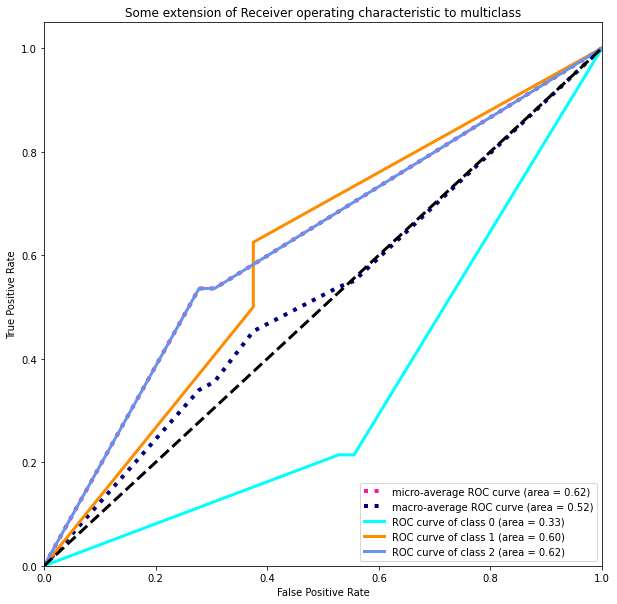

In [33]:
# First aggregate all false positive rates
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
lw = 3

# Then interpolate all ROC curves at this points
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += interp(all_fpr, fpr[i], tpr[i])

# Finally average it and compute AUC
mean_tpr /= n_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc_macro = auc(fpr["macro"], tpr["macro"])

data={"macro":roc_auc_macro, "micro":roc_auc_micro}
roc_auc_t = pd.Series(data=data, index=["macro", "micro"])

# Plot all ROC curves
plt.figure(figsize=(10,10))
plt.plot(
    fpr["micro"],
    tpr["micro"],
    label="micro-average ROC curve (area = {0:0.2f})".format(roc_auc_t["micro"]),
    color="deeppink",
    linestyle=":",
    linewidth=4,
)

plt.plot(
    fpr["macro"],
    tpr["macro"],
    label="macro-average ROC curve (area = {0:0.2f})".format(roc_auc_t["macro"]),
    color="navy",
    linestyle=":",
    linewidth=4,
)


colors = cycle(["aqua", "darkorange", "cornflowerblue"])
for i, color in zip(range(n_classes), colors):
  plt.plot(
      fpr[i],
      tpr[i],
      color=color,
      lw=lw,
      label="ROC curve of class {0} (area = {1:0.2f})".format(i, roc_auc[(i)]),
  )

plt.plot([0, 1], [0, 1], "k--", lw=lw)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Some extension of Receiver operating characteristic to multiclass")
plt.legend(loc="lower right")
plt.show()